# dsc148 final prooject
ncaa predicting if a cinderalla team wins against competitor 

Dependencies

In [13]:
# dependencies
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

Datasets

In [20]:
df_men_regular = pd.read_csv('march-machine-learning-mania-2026/MRegularSeasonCompactResults.csv')
df_seeds = pd.read_csv('march-machine-learning-mania-2026/MNCAATourneySeeds.csv')
df_tourney = pd.read_csv('march-machine-learning-mania-2026/MNCAATourneyCompactResults.csv')
df_detailed = pd.read_csv('march-machine-learning-mania-2026/MRegularSeasonDetailedResults.csv')
df_massey = pd.read_csv('march-machine-learning-mania-2026/MMasseyOrdinals.csv')

Data Processing + Early Analysis

Regular Season 

In [8]:
print("Seasons covered:", df_men_regular['Season'].min(), "to", df_men_regular['Season'].max())
print("Day number range:", df_men_regular['DayNum'].min(), "to", df_men_regular['DayNum'].max())
print(df_men_regular['WLoc'].value_counts(normalize=True))
print(df_men_regular[['WScore', 'LScore']].describe())

Seasons covered: 1985 to 2026
Day number range: 0 to 132
WLoc
H    0.589968
A    0.307352
N    0.102681
Name: proportion, dtype: float64
              WScore         LScore
count  198577.000000  198577.000000
mean       76.978839      64.891276
std        11.823352      11.201117
min        34.000000      20.000000
25%        69.000000      57.000000
50%        76.000000      64.000000
75%        84.000000      72.000000
max       186.000000     150.000000


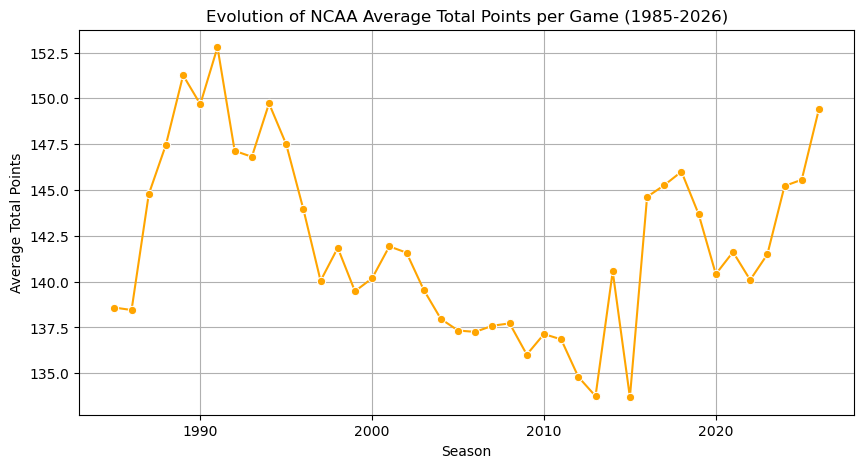

In [10]:
# Calculate total points per game
df_men_regular['TotalPoints'] = df_men_regular['WScore'] + df_men_regular['LScore']

# Group by season and calculate the average
yearly_scores = df_men_regular.groupby('Season')['TotalPoints'].mean().reset_index()

# Plot the evolution
plt.figure(figsize=(10, 5))
sns.lineplot(data=yearly_scores, x='Season', y='TotalPoints', marker='o', color='orange')
plt.title('Evolution of NCAA Average Total Points per Game (1985-2026)')
plt.ylabel('Average Total Points')
plt.xlabel('Season')
plt.grid(True)
plt.show()

In [17]:
# Calculate regular season stats from the perspective of when a team wins
w_detailed = df_detailed.groupby(['Season', 'WTeamID']).agg(
    W_FGA=('WFGA', 'sum'), W_TO=('WTO', 'sum'), W_FTA=('WFTA', 'sum'), W_OR=('WOR', 'sum'),
    W_FGA3=('WFGA3', 'sum'), W_FGM3=('WFGM3', 'sum'), W_Games=('WScore', 'count')
).reset_index().rename(columns={'WTeamID': 'TeamID'})

# Calculate regular season stats from the perspective of when a team loses
l_detailed = df_detailed.groupby(['Season', 'LTeamID']).agg(
    L_FGA=('LFGA', 'sum'), L_TO=('LTO', 'sum'), L_FTA=('LFTA', 'sum'), L_OR=('LOR', 'sum'),
    L_FGA3=('LFGA3', 'sum'), L_FGM3=('LFGM3', 'sum'), L_Games=('LScore', 'count')
).reset_index().rename(columns={'LTeamID': 'TeamID'})

# Merge seasonal stats
team_stats = pd.merge(w_detailed, l_detailed, on=['Season', 'TeamID'], how='outer').fillna(0)

# Aggregate core counts
team_stats['TotalGames'] = team_stats['W_Games'] + team_stats['L_Games']
team_stats['TotalFGA'] = team_stats['W_FGA'] + team_stats['L_FGA']
team_stats['TotalTO'] = team_stats['W_TO'] + team_stats['L_TO']
team_stats['TotalFTA'] = team_stats['W_FTA'] + team_stats['L_FTA']
team_stats['TotalOR'] = team_stats['W_OR'] + team_stats['L_OR']
team_stats['TotalFGA3'] = team_stats['W_FGA3'] + team_stats['L_FGA3']
team_stats['TotalFGM3'] = team_stats['W_FGM3'] + team_stats['L_FGM3']

# --- FEATURE ENGINEERING ---

# Feature 1: Estimate Team Pace (Possessions per game)
# Basketball formula: FGA + 0.475 * FTA + TO - OR
team_stats['TotalPossessions'] = team_stats['TotalFGA'] + (0.475 * team_stats['TotalFTA']) + team_stats['TotalTO'] - team_stats['TotalOR']
team_stats['Pace'] = team_stats['TotalPossessions'] / team_stats['TotalGames']

# Feature 2: 3-Point Rate (What % of their shots are from deep?)
team_stats['ThreePointRate'] = team_stats['TotalFGA3'] / team_stats['TotalFGA']

# Feature 3: 3-Point Accuracy
team_stats['ThreePointPct'] = team_stats['TotalFGM3'] / team_stats['TotalFGA3']

# Final clean feature lookup table
df_features = team_stats[['Season', 'TeamID', 'Pace', 'ThreePointRate', 'ThreePointPct']]
print(df_features.head())

   Season  TeamID       Pace  ThreePointRate  ThreePointPct
0    2003    1102  55.161607        0.523339       0.375643
1    2003    1103  70.983333        0.287798       0.338710
2    2003    1104  66.833929        0.347283       0.320144
3    2003    1105  77.146154        0.337079       0.364815
4    2003    1106  67.856250        0.319121       0.346154


Seeds and Tournament Data Processing

In [15]:
# 2. Extract the integer seed (e.g., 'W11a' -> 11)
df_seeds['SeedInt'] = df_seeds['Seed'].apply(lambda x: int(''.join(filter(str.isdigit, x))))

# 3. Filter strictly for low seeds (11 through 16)
df_low_seeds = df_seeds[df_seeds['SeedInt'] >= 11].copy()

# 4. Calculate how many tournament wins each team got that season
win_counts = df_tourney.groupby(['Season', 'WTeamID']).size().reset_index(name='TourneyWins')

# 5. Merge wins back onto our low seeds dataframe
df_cinderella = df_low_seeds.merge(
    win_counts, 
    left_on=['Season', 'TeamID'], 
    right_on=['Season', 'WTeamID'], 
    how='left'
).fillna(0)

# 6. Define the Target Variable (Y = 1 if they won 2+ games to reach the Sweet 16)
df_cinderella['Cinderella'] = (df_cinderella['TourneyWins'] >= 2).astype(int)

# Clean up dataframe
df_base_population = df_cinderella[['Season', 'TeamID', 'SeedInt', 'Cinderella']]
print(df_base_population['Cinderella'].value_counts())
print(f"Baseline Class Imbalance: {df_base_population['Cinderella'].mean():.2%} are Cinderellas.")

Cinderella
0    984
1     68
Name: count, dtype: int64
Baseline Class Imbalance: 6.46% are Cinderellas.


In [11]:
# 1. Load the Tournament Results and the Seeds
df_seeds = pd.read_csv('march-machine-learning-mania-2026/MNCAATourneySeeds.csv')
df_tourney = pd.read_csv('march-machine-learning-mania-2026/MNCAATourneyCompactResults.csv')

# 2. Clean up the Seed column to extract just the integer (e.g., 'W01' -> 1)
df_seeds['SeedInt'] = df_seeds['Seed'].apply(lambda x: int(x[1:3]))

# 3. Merge seeds onto the winning team and losing team
df_tourney = df_tourney.merge(df_seeds[['Season', 'TeamID', 'SeedInt']], left_on=['Season', 'WTeamID'], right_on=['Season', 'TeamID']).rename(columns={'SeedInt': 'WSeed'})
df_tourney.drop(columns=['TeamID'], inplace=True)

df_tourney = df_tourney.merge(df_seeds[['Season', 'TeamID', 'SeedInt']], left_on=['Season', 'LTeamID'], right_on=['Season', 'TeamID']).rename(columns={'SeedInt': 'LSeed'})
df_tourney.drop(columns=['TeamID'], inplace=True)

# 4. Calculate the Seed Differential (Winning Seed minus Losing Seed)
df_tourney['SeedDiff'] = df_tourney['WSeed'] - df_tourney['LSeed']

# Let's see how often the better (lower-numbered) seed actually wins!
better_seed_won = (df_tourney['WSeed'] < df_tourney['LSeed']).mean()
print(f"Percentage of tournament games won by the better seed: {better_seed_won:.2%}")

Percentage of tournament games won by the better seed: 68.94%


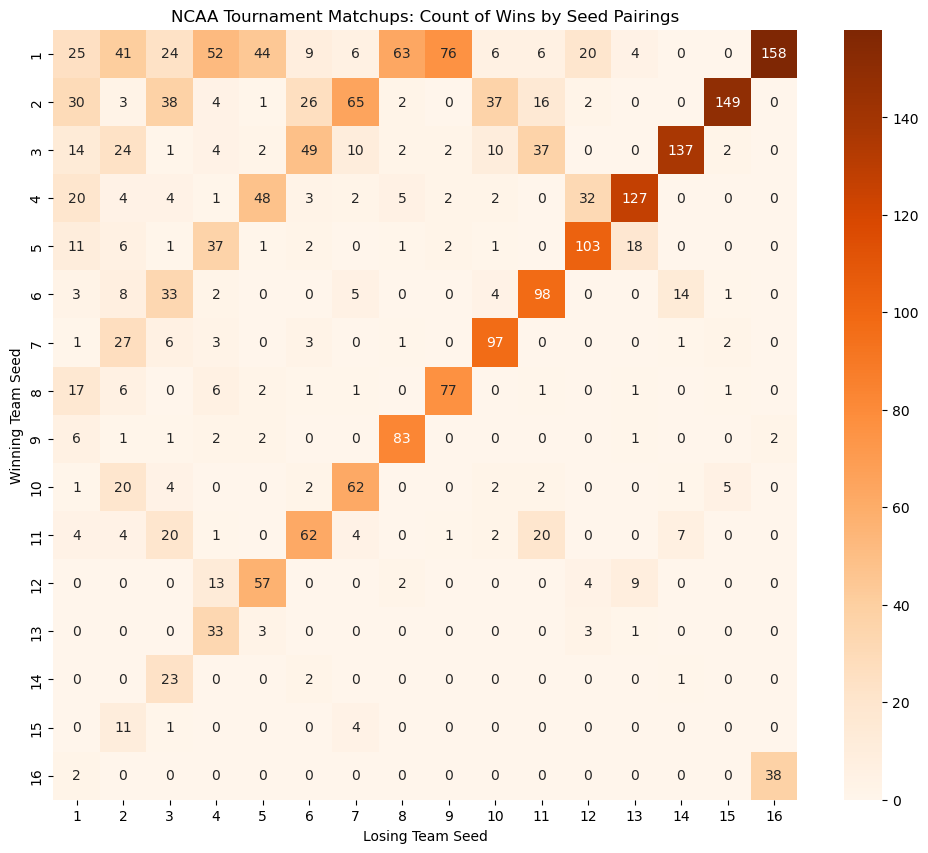

In [12]:
# Create a pivot table of Winner Seed vs Loser Seed for all historical tournament games
upset_matrix = pd.crosstab(df_tourney['WSeed'], df_tourney['LSeed'])

# Let's look specifically at when a lower seed (higher number, e.g., 11, 12) beats a top seed

plt.figure(figsize=(12, 10))
sns.heatmap(upset_matrix, annot=True, fmt='d', cmap='Oranges', cbar=True)
plt.title('NCAA Tournament Matchups: Count of Wins by Seed Pairings')
plt.xlabel('Losing Team Seed')
plt.ylabel('Winning Team Seed')
plt.show()

Feature Engineering

In [18]:
# Merge our population with our engineered features
df_final_eda = df_base_population.merge(df_features, on=['Season', 'TeamID'], how='inner')

# Group by the Cinderella status and look at the average features
print(df_final_eda.groupby('Cinderella')[['Pace', 'ThreePointRate', 'ThreePointPct']].mean())

                 Pace  ThreePointRate  ThreePointPct
Cinderella                                          
0           68.510813        0.352397       0.355686
1           67.709341        0.350142       0.354879


In [21]:


# 2. Filter for the final pre-tournament rankings (Day 133) 
# We will use the 'POM' (Pomeroy) system as a robust baseline example, or aggregate across multiple
df_pre_tourney = df_massey[(df_massey['RankingDayNum'] == 133) & (df_massey['SystemName'] == 'POM')].copy()

# 3. Select relevant ranking columns
df_ranks = df_pre_tourney[['Season', 'TeamID', 'OrdinalRank']].rename(columns={'OrdinalRank': 'PreTourneyRank'})

# 4. Merge these public perception metrics into your main EDA dataframe
df_final_eda = df_final_eda.merge(df_ranks, on=['Season', 'TeamID'], how='inner')

# 5. Let's look at the average rank of a standard low seed vs a Cinderella!
print(df_final_eda.groupby('Cinderella')['PreTourneyRank'].mean())

KeyError: 'Column not found: PreTourneyRank'